# Week 9 demos

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress

## Loading and inspect netcdf data

In [2]:
# loading NOAA ice concentration data
data = xr.open_dataset('data/icec.mnmean.nc')
display(data)

<xarray.Dataset> Size: 128MB
Dimensions:    (time: 494, lat: 180, lon: 360, nbnds: 2)
Coordinates:
  * lat        (lat) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon        (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) datetime64[ns] 4kB 1981-12-01 1982-01-01 ... 2023-01-01
Dimensions without coordinates: nbnds
Data variables:
    icec       (time, lat, lon) float32 128MB ...
    time_bnds  (time, nbnds) datetime64[ns] 8kB ...
Attributes:
    title:          NOAA Optimum Interpolation (OI) SST V2
    Conventions:    CF-1.0
    history:        Wed Apr  6 13:51:42 2005: ncks -d time,0,278 SAVEs/icec.m...
    comments:       Data described in  Reynolds, R.W., N.A. Rayner, T.M.\nSmi...
    platform:       Model
    source:         NCEP Climate Modeling Branch
    institution:    National Centers for Environmental Prediction
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    NCO:            4.0.0
    dataset_title:  NOAA Optimum Interpolation (OI) SST V2
    source_url:     http://www.emc.ncep.noaa.gov/research/cmb/sst_analysis/

In [3]:
# extract monthly means of ice concentration DataArray from the Dataset
ice = data.icec
display(ice)

<xarray.DataArray 'icec' (time: 494, lat: 180, lon: 360)> Size: 128MB
[32011200 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) datetime64[ns] 4kB 1981-12-01 1982-01-01 ... 2023-01-01
Attributes:
    long_name:             Monthly Means of Ice Concentration
    unpacked_valid_range:  [  0. 100.]
    actual_range:          [  0. 122.]
    units:                 %
    precision:             2
    var_desc:              Ice Concentration
    dataset:               NOAA Optimum Interpolation (OI) SST V2
    level_desc:            Surface
    statistic:             Mean
    parent_stat:           Weekly Mean
    cell_methods:          time: mean (monthly from weekly values interpolate...
    valid_range:           [-32765 -22765]

## Dimensional reduction on xarray DataArray

### Poll #1 (think-pair-share; Jupyter **Off**)

Which of the following codes can be used to reduce the dimension of the sea ice concentration data by making an average over sea ice concentration in the part of the globe where latitude is above 45°N?

1. ```python
   ice.mean('lat').mean('lon')
   ```
   
2. ```python
   ice.sel(lat = ice.lat > 45).mean('lat')
   ```

3. ```python
   ice.sel(lat = ice.lat > 45).mean('lon')
   ```

4. ```python
   ice.sel(lat = ice.lat > 45).mean(['lat', 'lon'])
   ```

In [4]:
ice_mean = ice.sel(lat = ice.lat > 45).mean(['lat', 'lon'])

In [5]:
display(ice_mean)

<xarray.DataArray 'icec' (time: 494)> Size: 2kB
array([61.240326, 64.90976 , 66.17007 , 66.37532 , 65.59003 , 62.53763 ,
       58.50266 , 51.152317, 45.524765, 43.847683, 51.00223 , 57.443985,
       61.406464, 63.74341 , 65.397644, 65.27296 , 64.045815, 61.505848,
       57.421555, 50.4696  , 44.80846 , 43.188774, 50.44579 , 57.459717,
       61.242664, 63.34832 , 63.85927 , 64.774765, 64.16741 , 61.468643,
       57.34375 , 48.697918, 43.06845 , 41.353848, 47.89817 , 54.95791 ,
       59.521683, 62.36905 , 64.41465 , 64.71248 , 65.10491 , 62.49628 ,
       56.71694 , 47.413372, 42.237457, 41.362885, 48.25234 , 55.799534,
       60.229485, 63.906357, 65.103745, 65.48353 , 64.3108  , 61.756165,
       57.82334 , 50.223534, 45.210354, 44.48735 , 51.245747, 56.805805,
       60.781994, 63.464073, 66.14892 , 65.752235, 64.98767 , 62.02349 ,
       58.521683, 50.75893 , 44.71216 , 44.52955 , 51.204933, 57.499786,
       61.797726, 64.54135 , 65.439095, 66.18984 , 65.17634 , 60.821533,
       56.355335, 48.735756, 44.171345, 43.639244, 51.010735, 58.160606,
       62.999256, 65.291245, 65.384995, 64.944725, 63.114582, 60.764774,
       57.31335 , 50.031464, 45.12415 , 42.493942, 49.391262, 56.30527 ,
       61.476402, 63.36416 , 64.059204, 64.92528 , 62.18346 , 58.886585,
       54.89041 , 46.81994 , 41.81388 , 39.83833 , 47.796238, 56.923576,
       60.96333 , 62.80219 , 64.07961 , 64.74181 , 63.558247, 60.9324  ,
       56.158165, 47.860863, 42.915283, 40.0203  , 48.47364 , 56.076637,
...
       54.23639 , 45.118137, 37.79421 , 34.174896, 43.347656, 52.853664,
       58.590504, 61.28903 , 62.372826, 63.12683 , 62.933   , 59.753315,
       53.77925 , 45.699776, 39.157875, 34.84006 , 43.38432 , 54.266335,
       59.378918, 62.251106, 64.03213 , 63.798702, 62.32498 , 59.12909 ,
       53.149426, 44.657825, 35.968563, 33.749386, 42.14579 , 52.231655,
       57.666275, 60.338737, 61.321644, 61.98772 , 61.399254, 57.53365 ,
       51.73062 , 43.338837, 34.396603, 31.725021, 39.05364 , 46.32734 ,
       53.757343, 58.03478 , 60.528637, 61.758816, 61.412125, 58.548874,
       51.930447, 42.22409 , 34.62452 , 32.85824 , 40.466156, 49.74005 ,
       55.753315, 59.424107, 60.278614, 61.753216, 61.434128, 57.53895 ,
       52.375874, 44.90009 , 36.81668 , 34.243343, 38.60566 , 51.82641 ,
       57.544945, 61.739265, 63.325375, 63.893017, 62.08321 , 58.613323,
       52.889084, 43.407406, 34.91787 , 33.36831 , 38.870224, 51.65016 ,
       58.556637, 62.170155, 63.882404, 64.51046 , 62.82729 , 58.990078,
       52.5085  , 41.842224, 33.4862  , 30.052755, 36.303566, 49.212986,
       57.258278, 61.092445, 63.745556, 64.18538 , 62.457314, 59.63366 ,
       53.2179  , 43.770214, 36.670696, 34.94479 , 42.04873 , 53.096275,
       59.040474, 62.368797, 63.64358 , 63.547108, 63.128403, 60.153355,
       53.188133, 44.55575 , 37.722076, 34.875526, 41.722862, 52.677277,
       32.157875, 60.951763], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-12-01 1982-01-01 ... 2023-01-01

## Conversion to pandas dataframe

In [7]:
# convert the time series from xarray to pandas
ice_df = ice_mean.to_dataframe().reset_index()
display(ice_df)

,time,icec
0,1981-12-01,61.240326
1,1982-01-01,64.909760
2,1982-02-01,66.170067
3,1982-03-01,66.375320
4,1982-04-01,65.590027
...,...,...
489,2022-09-01,34.875526
490,2022-10-01,41.722862
491,2022-11-01,52.677277
492,2022-12-01,32.157875


In [8]:
ice_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    494 non-null    datetime64[ns]
 1   icec    494 non-null    float32       
dtypes: datetime64[ns](1), float32(1)
memory usage: 5.9 KB


## Plotting the time series

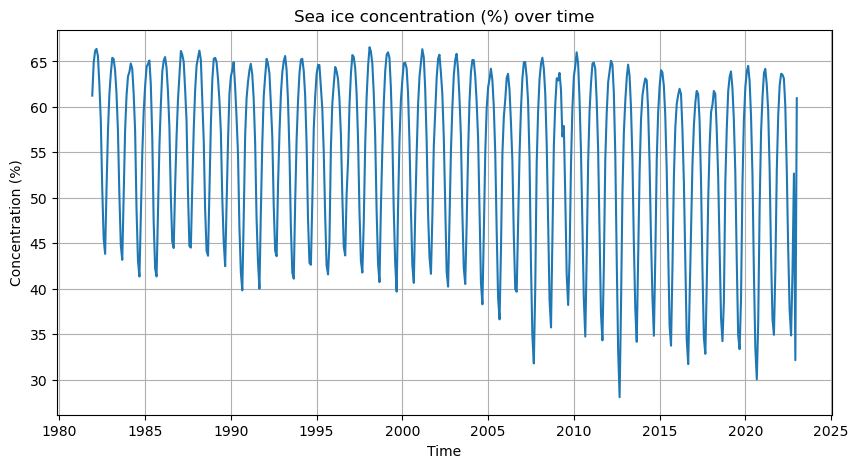

In [11]:
# Starter code

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()

ax.plot(ice_df.time, ice_df.icec)

ax.set_title("Sea ice concentration (%) over time")
ax.set_xlabel("Time")
ax.set_ylabel("Concentration (%)")
ax.grid()
plt.show(fig)

### Think-pair-share

What have you noticed from the plot above?

## Linear regression

In [12]:
# convert the timestamp to floating point numbers
ice_time_day = (ice_df.time - ice_df.time[0]) / np.timedelta64(1, 'D')

### Your turn #1

Perform the linear regression of mean ice concentration against time, then print and inspect the results (intercept, slope, R<sup>2</sup> and r)

In [16]:
# Your code here
ice_trend = linregress(ice_time_day, ice_df.icec.values)
print(ice_trend)
print("R^2 = ", ice_trend.rvalue ** 2)

LinregressResult(slope=-0.00045913939696289366, intercept=58.20669432305019, rvalue=-0.2094298127941623, pvalue=2.663652928330544e-06, stderr=9.664603802342551e-05, intercept_stderr=0.8376998139827407)
R^2 =  0.043860846486997875


In [22]:
print("change over 45 years =", ice_trend.slope * 365.2425 * 45, "%")

change over 45 years =  -7.546374953784886 %


### Think-pair-share

How would you interpret the results from the linear fit?

### Your turn #2

Add the regression line to the previous plot. Make sure you follow best practices for good plot

In [23]:
# Create the y (ice concentration) coordindates of the regression line
ice_fit = ice_trend.intercept + ice_trend.slope * ice_time_day

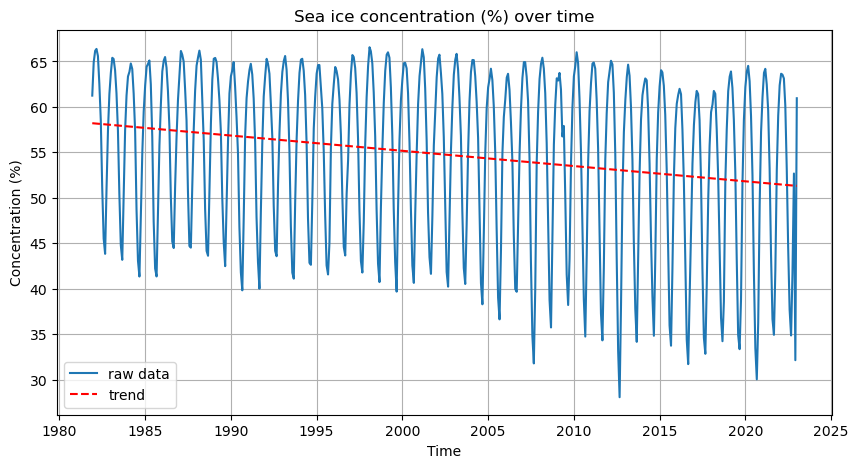

In [24]:
# Your code here
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot()

ax.plot(ice_df.time, ice_df.icec, label="raw data")
ax.plot(ice_df.time, ice_fit, label="trend", c="red", ls="--")

ax.set_title("Sea ice concentration (%) over time")
ax.set_xlabel("Time")
ax.set_ylabel("Concentration (%)")
ax.grid()
ax.legend()

plt.show(fig)

## Grouped summarization: climatology and anomaly

In [25]:
# Climatology
# Take the monthly mean (e.g. Mean ice concentration in January for all years, february for all years, etc.)
ice_mean_climatology = ice_df["icec"].groupby(ice_df.time.dt.month).mean()
display(ice_mean_climatology)

time
1     62.752533
2     64.305946
3     64.729858
4     63.563011
5     60.455952
6     55.498737
7     47.175488
8     40.491695
9     38.416801
10    45.735039
11    54.592197
12    59.125000
Name: icec, dtype: float32

In [26]:
# Anomalies
# These are deviations from the mean seasonal cycle
ice_mean_anomalies = ice_df["icec"] - ice_mean_climatology.loc[ice_df.time.dt.month].values
display(ice_mean_anomalies)

0       2.115326
1       2.157227
2       1.864120
3       1.645462
4       2.027016
         ...    
489    -3.541275
490    -4.012177
491    -1.914921
492   -26.967125
493    -1.800770
Name: icec, Length: 494, dtype: float32

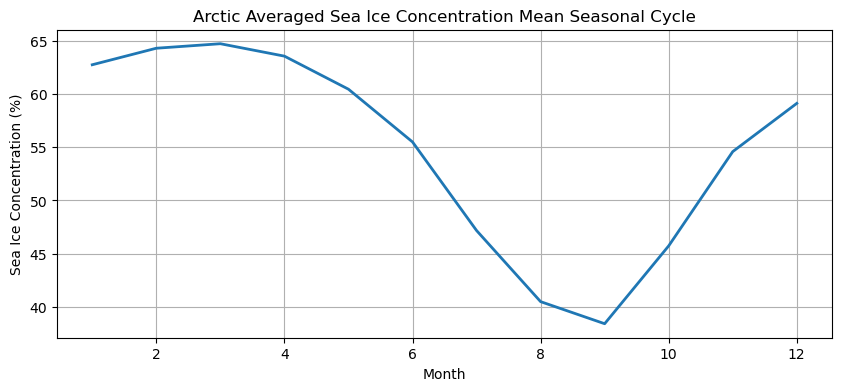

In [27]:
fig = plt.figure(figsize = (10, 4))
ax = fig.add_subplot()

ax.plot(np.arange(1, 13, 1), ice_mean_climatology, lw=2)
ax.set_xlabel('Month')
ax.set_ylabel('Sea Ice Concentration (%)')
ax.set_title('Arctic Averaged Sea Ice Concentration Mean Seasonal Cycle')
ax.grid()

plt.show(fig)

## Multi-panel plot

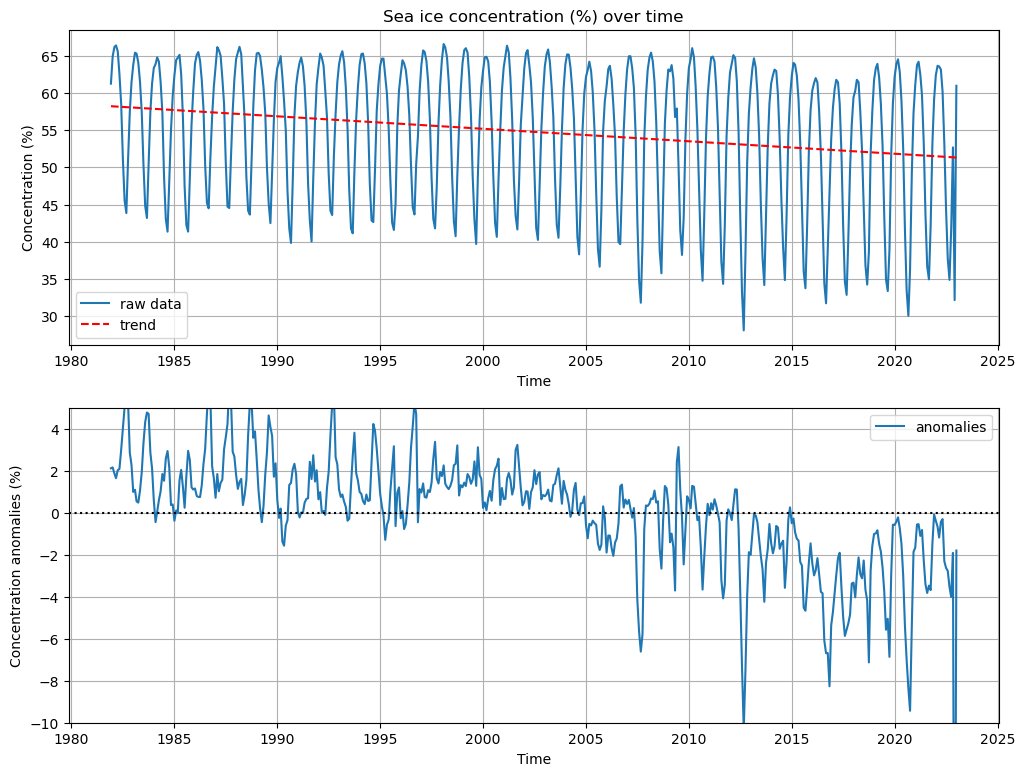

In [35]:
fig = plt.figure(figsize=(12, 9))

# Upper panel: sea ice concentration and trend
ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(ice_df.time, ice_df.icec, label="raw data")
ax1.plot(ice_df.time, ice_fit, label="trend", c="red", ls="--")

ax1.set_title("Sea ice concentration (%) over time")
ax1.set_xlabel("Time")
ax1.set_ylabel("Concentration (%)")
ax1.grid()
ax1.legend()

# Lower panel: sea ice concentration anomalies
ax2 = fig.add_subplot(2, 1, 2, sharex=ax1)

ax2.plot(ice_df.time, ice_mean_anomalies, label="anomalies")
ax2.axhline(0, ls=":", c="black")
ax2.set_xlabel("Time")
ax2.set_ylabel("Concentration anomalies (%)")
ax2.set_ylim([-10, 5])
ax2.grid()
ax2.legend()

plt.show(fig)

## _(Optional) redo linear regression on anomaly data_

In [37]:
# Your code here
ice_anom_trend = linregress(ice_time_day, ice_mean_anomalies.values)
print(ice_anom_trend)
print("R^2 = ", ice_anom_trend.rvalue ** 2)

LinregressResult(slope=-0.00043161309303578065, intercept=3.2382126819813917, rvalue=-0.6657759811175838, pvalue=1.452973091565281e-64, stderr=2.180776016705756e-05, intercept_stderr=0.18902333721012313)
R^2 =  0.44325765703308134


### Think Pair Share

Compare the result of _this_ linear regression to the previous one, what have you noticed? Does the result make sense?

## _(Optional) a more complicated multi-panel plot_

In [38]:
# trick: insert nan between month = 12 and month = 1

tmp = np.array([ice_df.time.dt.month.values, ice_df.icec.values]).T
ice_month = np.array([[0, 0]])

for row in tmp:
    ice_month = np.append(ice_month, [row], axis=0)
    if row[0] == 12:
        ice_month = np.append(ice_month, [[np.nan, np.nan]], axis=0)

ice_month = ice_month[1:]

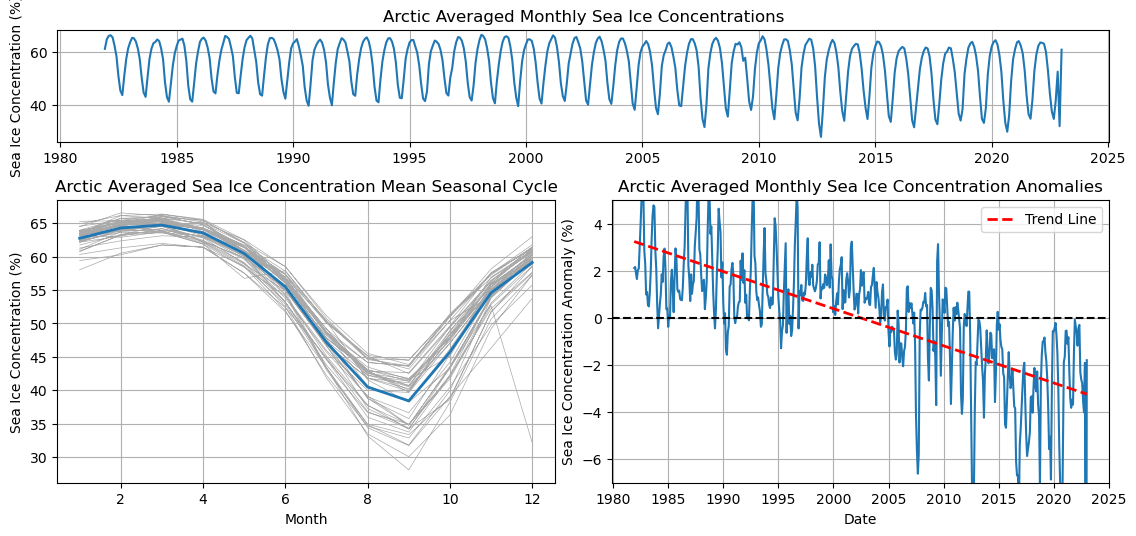

In [41]:
fig = plt.figure(figsize=(12, 6))

# Top panel: sea ice concentration

ax0 = fig.add_subplot(3, 2, (1, 2))

ax0.plot(ice_df.time, ice_df.icec)
ax0.set_title('Arctic Averaged Monthly Sea Ice Concentrations')
ax0.set_ylabel('Sea Ice Concentration (%)')
ax0.grid()

# Lower left: climatology

ax1 = fig.add_subplot(3, 2, (3, 5))

ax1.plot(ice_month[:, 0], ice_month[:, 1], lw=0.5, color="darkgray" )
ax1.plot(np.arange(1, 13, 1), ice_mean_climatology, lw=2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Sea Ice Concentration (%)')
ax1.set_title('Arctic Averaged Sea Ice Concentration Mean Seasonal Cycle')
ax1.grid()

# Lower right: sea ice concentration anomalies

ax2 = fig.add_subplot(3, 2, (4, 6))

ax2.plot(ice_df.time, ice_mean_anomalies)
ax2.plot(ice_df.time, ice_anom_fit, label='Trend Line', color='red', ls = '--', lw = 2)
ax2.set_title('Arctic Averaged Monthly Sea Ice Concentration Anomalies')
ax2.set_xlabel('Date')
ax2.set_ylabel('Sea Ice Concentration Anomaly (%)')
ax2.axhline(y = 0, color = 'k', ls = '--') # Helpful for anomalies to have reference line
ax2.set_ylim(-7,5)
ax2.legend()
ax2.grid()

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0)
fig.savefig("ice_illustration.png")
plt.show(fig)